# 🧬 Projet : Recommandation des Maladies-Gènes par Prédiction des Liens
## 🤖 Phase 6 — Méthodes d'Intelligence Artificielle

---

### 🎯 Objectif de cette phase
Dépasser les performances faibles des baselines (AUC ~0.57) avec deux approches IA :

| Méthode | Idée principale |
|---|---|
| **Node2Vec** | Marches aléatoires sur le graphe → vecteur par nœud → classifieur |
| **GAE (Autoencoder)** | Factorisation de la matrice d'adjacence → vecteur par nœud |

---

### 📖 Pourquoi ça devrait marcher mieux que la Phase 5
Les heuristiques baseline (Jaccard, Adamic-Adar...) ne regardent que les voisins
directs ou à 2 sauts. Node2Vec et GAE apprennent une représentation qui capture
des structures beaucoup plus globales du graphe, ce qui leur permet de détecter
des patterns invisibles aux méthodes simples.

## ⚙️ Cellule 1 — Installation et importation

In [ ]:
# !pip install node2vec gensim scikit-learn scipy

import os, pickle, time, warnings, copy
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from node2vec import Node2Vec
from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD, PCA

from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline       import Pipeline
from sklearn.metrics        import (
    roc_auc_score, roc_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print('✅ Bibliothèques importées avec succès !')

c:\Users\EL MAHDI MAJDI\AppData\Local\Programs\Python\Python310\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(
c:\Users\EL MAHDI MAJDI\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Bibliothèques importées avec succès !


## 📁 Cellule 2 — Chargement des données (Phases 3, 4, 5)

In [2]:
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
SPLIT_DIR   = os.path.join(BASE_DIR, 'data',    'splits')
EMB_DIR     = os.path.join(BASE_DIR, 'data',    'embeddings')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
FIG_DIR     = os.path.join(BASE_DIR, 'results', 'figures')

os.makedirs(EMB_DIR, exist_ok=True)

with open(os.path.join(SPLIT_DIR, 'G_train.pkl'), 'rb') as f:
    G_train = pickle.load(f)

df_train = pd.read_csv(os.path.join(SPLIT_DIR, 'train_data.csv'))
df_test  = pd.read_csv(os.path.join(SPLIT_DIR, 'test_data.csv'))

# AUC de référence (meilleure baseline Phase 5)
df_baseline = pd.read_csv(os.path.join(RESULTS_DIR, 'baseline_metrics.csv'))
best_baseline_auc = df_baseline['AUC-ROC'].max()
best_baseline_name = df_baseline.loc[df_baseline['AUC-ROC'].idxmax(), 'Méthode']

print('✅ Données chargées !')
print(f'   G_train  : {G_train.number_of_nodes():,} nœuds, {G_train.number_of_edges():,} arêtes')
print(f'   Train    : {len(df_train):,} exemples')
print(f'   Test     : {len(df_test):,} exemples')
print(f'\n📊 Référence à battre : {best_baseline_name} (AUC = {best_baseline_auc:.4f})')

✅ Données chargées !
   G_train  : 16,555 nœuds, 12,752 arêtes
   Train    : 25,504 exemples
   Test     : 6,376 exemples

📊 Référence à battre : CN Bipartite (AUC = 0.5751)


## 🔵 Cellule 3 — Entraînement Node2Vec

In [3]:
DIMENSIONS  = 64
WALK_LENGTH = 20
NUM_WALKS   = 50
P, Q        = 1, 1
WINDOW      = 5

EMB_PATH = os.path.join(EMB_DIR, 'node2vec_embeddings.pkl')

if os.path.exists(EMB_PATH):
    print('✅ Embeddings déjà calculés — chargement...')
    with open(EMB_PATH, 'rb') as f:
        embeddings = pickle.load(f)
else:
    print('⏳ Entraînement Node2Vec en cours (peut prendre plusieurs minutes)...')
    t0 = time.time()

    node2vec = Node2Vec(
        G_train,
        dimensions  = DIMENSIONS,
        walk_length = WALK_LENGTH,
        num_walks   = NUM_WALKS,
        p = P, q = Q,
        workers = 2,
        quiet = False
    )
    model = node2vec.fit(window=WINDOW, min_count=1, batch_words=4)

    embeddings = {node: model.wv[node] for node in G_train.nodes() if node in model.wv}

    with open(EMB_PATH, 'wb') as f:
        pickle.dump(embeddings, f)

    print(f'\n✅ Terminé en {time.time()-t0:.0f}s')

print(f'\n📊 {len(embeddings):,} nœuds embeddés, dimension = {DIMENSIONS}')

⏳ Entraînement Node2Vec en cours (peut prendre plusieurs minutes)...


Computing transition probabilities: 100%|██████████| 16555/16555 [00:02<00:00, 7577.26it/s] 



✅ Terminé en 1272s

📊 16,555 nœuds embeddés, dimension = 64


## 📍 Cellule 4 — Visualisation des embeddings (PCA)

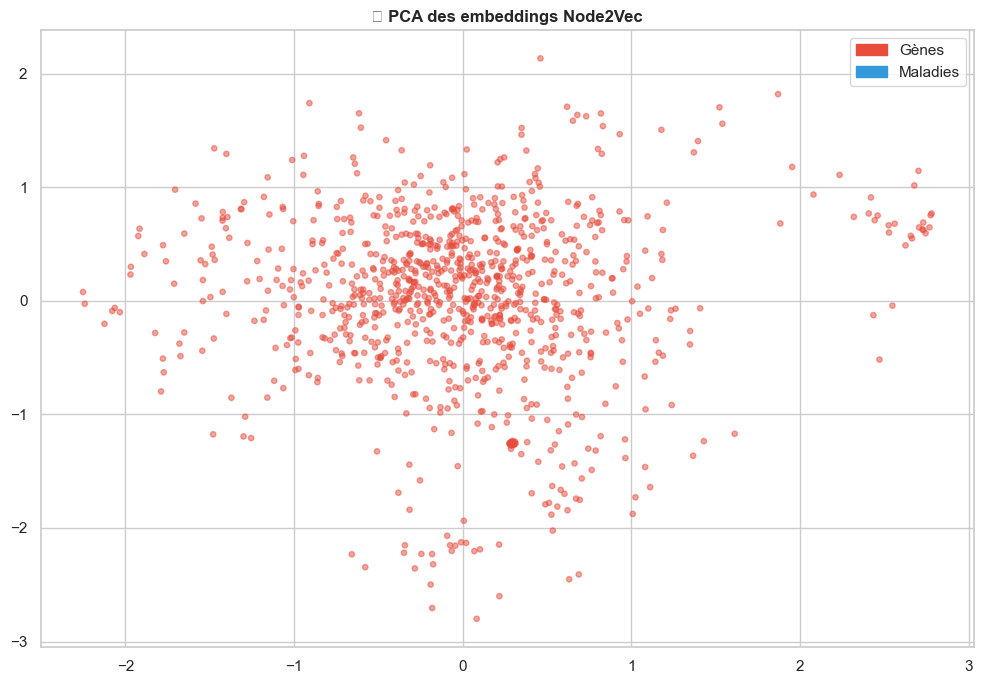

Variance expliquée : 6.9%


In [4]:
nodes_list = list(embeddings.keys())[:1000]
vectors    = np.array([embeddings[n] for n in nodes_list])
types      = ['Gène' if G_train.nodes[n].get('node_type')=='gene'
              else 'Maladie' for n in nodes_list]

pca = PCA(n_components=2, random_state=42)
result = pca.fit_transform(vectors)

colors = ['#E74C3C' if t=='Gène' else '#3498DB' for t in types]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(result[:,0], result[:,1], c=colors, alpha=0.5, s=15)
ax.legend(handles=[mpatches.Patch(color='#E74C3C', label='Gènes'),
                   mpatches.Patch(color='#3498DB', label='Maladies')])
ax.set_title('📍 PCA des embeddings Node2Vec', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'node2vec_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f}%')

## 🔧 Cellule 5 — Construction des features pour la prédiction de liens

In [5]:
def get_edge_features(u, v, emb, operator='hadamard'):
    if u not in emb or v not in emb:
        dim = len(next(iter(emb.values())))
        return np.zeros(dim)
    eu, ev = emb[u], emb[v]
    if operator == 'hadamard': return eu * ev
    elif operator == 'L1':     return np.abs(eu - ev)
    elif operator == 'average':return (eu + ev) / 2
    return eu * ev

def build_feature_matrix(df, emb, operator='hadamard'):
    X = np.array([get_edge_features(r.node1, r.node2, emb, operator)
                  for r in df.itertuples()])
    y = df['label'].values
    return X, y

print('⏳ Construction des matrices de features...')
X_train, y_train = build_feature_matrix(df_train, embeddings, 'hadamard')
X_test,  y_test  = build_feature_matrix(df_test,  embeddings, 'hadamard')

print(f'✅ X_train : {X_train.shape}   X_test : {X_test.shape}')

⏳ Construction des matrices de features...
✅ X_train : (25504, 64)   X_test : (6376, 64)


## 🤖 Cellule 6 — Entraînement des classifieurs (Node2Vec)

In [6]:
classifiers = {
    'Régression Logistique': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
}

print('⏳ Entraînement des classifieurs...\n')
n2v_results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    ap    = average_precision_score(y_test, proba)
    n2v_results[name] = {'proba': proba, 'auc': auc, 'ap': ap}
    print(f'  {name:<25} AUC={auc:.4f}  AP={ap:.4f}')

best_n2v_name = max(n2v_results, key=lambda k: n2v_results[k]['auc'])
best_n2v_auc  = n2v_results[best_n2v_name]['auc']
print(f'\n🏆 Meilleur : {best_n2v_name} (AUC={best_n2v_auc:.4f})')
print(f'   vs Baseline = {best_baseline_auc:.4f}  '
      f'({"✅ MIEUX" if best_n2v_auc > best_baseline_auc else "⚠️ moins bien"})')

⏳ Entraînement des classifieurs...

  Régression Logistique     AUC=0.3436  AP=0.5173
  Random Forest             AUC=0.4025  AP=0.5502

🏆 Meilleur : Random Forest (AUC=0.4025)
   vs Baseline = 0.5751  (⚠️ moins bien)


## 🟣 Cellule 7 — GAE (Graph Autoencoder via SVD)

In [7]:
print('⏳ Construction matrice d\'adjacence + factorisation SVD...')

nodes_list  = list(G_train.nodes())
node_to_idx = {n: i for i, n in enumerate(nodes_list)}
N = len(nodes_list)

A = lil_matrix((N, N), dtype=np.float32)
for u, v in G_train.edges():
    i, j = node_to_idx[u], node_to_idx[v]
    A[i, j] = A[j, i] = 1.0

t0 = time.time()
svd = TruncatedSVD(n_components=64, random_state=42)
gae_matrix = svd.fit_transform(A.tocsr())
gae_embeddings = {nodes_list[i]: gae_matrix[i] for i in range(N)}

print(f'✅ GAE terminé en {time.time()-t0:.1f}s')
print(f'   Variance expliquée : {svd.explained_variance_ratio_.sum()*100:.1f}%')

⏳ Construction matrice d'adjacence + factorisation SVD...
✅ GAE terminé en 1.4s
   Variance expliquée : 9.9%


## 📊 Cellule 8 — Évaluation du GAE

In [8]:
X_train_g, y_train_g = build_feature_matrix(df_train, gae_embeddings, 'hadamard')
X_test_g,  y_test_g  = build_feature_matrix(df_test,  gae_embeddings, 'hadamard')

gae_results = {}
for name, clf in classifiers.items():
    clf_c = copy.deepcopy(clf)
    clf_c.fit(X_train_g, y_train_g)
    proba = clf_c.predict_proba(X_test_g)[:, 1]
    auc   = roc_auc_score(y_test_g, proba)
    ap    = average_precision_score(y_test_g, proba)
    gae_results[name] = {'proba': proba, 'auc': auc, 'ap': ap}
    print(f'  {name:<25} AUC={auc:.4f}  AP={ap:.4f}')

best_gae_name = max(gae_results, key=lambda k: gae_results[k]['auc'])
best_gae_auc  = gae_results[best_gae_name]['auc']
print(f'\n🏆 Meilleur GAE : {best_gae_name} (AUC={best_gae_auc:.4f})')

  Régression Logistique     AUC=0.5608  AP=0.6041
  Random Forest             AUC=0.6956  AP=0.6694

🏆 Meilleur GAE : Random Forest (AUC=0.6956)


## 📈 Cellule 9 — Courbes ROC comparatives (Baseline vs N2V vs GAE)

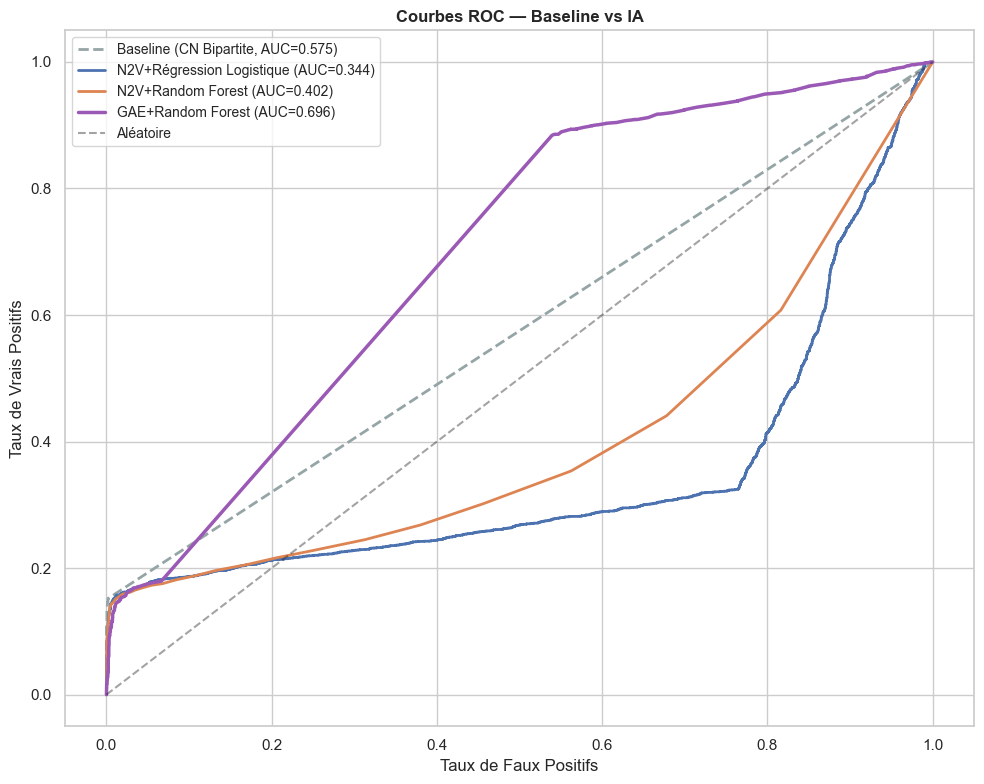

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

# Baseline
df_bs = pd.read_csv(os.path.join(RESULTS_DIR, 'baseline_scores.csv'))
fpr, tpr, _ = roc_curve(df_bs['label'], df_bs['score_JC'])
ax.plot(fpr, tpr, '--', color='#95A5A6', linewidth=2,
        label=f'Baseline ({best_baseline_name}, AUC={best_baseline_auc:.3f})')

# Node2Vec
for name, res in n2v_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, linewidth=2, label=f'N2V+{name} (AUC={res["auc"]:.3f})')

# GAE
fpr, tpr, _ = roc_curve(y_test_g, gae_results[best_gae_name]['proba'])
ax.plot(fpr, tpr, linewidth=2.5, color='#9B59B6',
        label=f'GAE+{best_gae_name} (AUC={best_gae_auc:.3f})')

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Aléatoire')
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbes ROC — Baseline vs IA', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ai_vs_baseline_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 📋 Cellule 10 — Tableau comparatif final

In [10]:
rows = [{'Méthode': best_baseline_name, 'Catégorie': 'Baseline',
         'AUC-ROC': round(best_baseline_auc, 4)}]

for name, res in n2v_results.items():
    rows.append({'Méthode': f'N2V+{name}', 'Catégorie': 'Node2Vec',
                 'AUC-ROC': round(res['auc'], 4)})

for name, res in gae_results.items():
    rows.append({'Méthode': f'GAE+{name}', 'Catégorie': 'GAE',
                 'AUC-ROC': round(res['auc'], 4)})

df_final = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False)
df_final.index = range(1, len(df_final)+1)

print('📊 TABLEAU COMPARATIF FINAL — Baseline vs IA\n')
print(df_final.to_string())

df_final.to_csv(os.path.join(RESULTS_DIR, 'final_comparison.csv'), index=False)
print('\n💾 Sauvegardé → results/final_comparison.csv')

📊 TABLEAU COMPARATIF FINAL — Baseline vs IA

                     Méthode Catégorie  AUC-ROC
1          GAE+Random Forest       GAE   0.6956
2               CN Bipartite  Baseline   0.5751
3  GAE+Régression Logistique       GAE   0.5608
4          N2V+Random Forest  Node2Vec   0.4025
5  N2V+Régression Logistique  Node2Vec   0.3436

💾 Sauvegardé → results/final_comparison.csv


## 💾 Cellule 11 — Sauvegarde du meilleur modèle

In [11]:
best_overall_auc = max(best_n2v_auc, best_gae_auc)

if best_n2v_auc >= best_gae_auc:
    final_model      = classifiers[best_n2v_name]
    final_embeddings = embeddings
    final_name       = f'N2V+{best_n2v_name}'
else:
    final_model      = classifiers[best_gae_name]
    final_embeddings = gae_embeddings
    final_name       = f'GAE+{best_gae_name}'

with open(os.path.join(RESULTS_DIR, 'best_model.pkl'), 'wb') as f:
    pickle.dump({'model': final_model, 'embeddings': final_embeddings,
                 'name': final_name, 'auc': best_overall_auc}, f)

print(f'💾 Meilleur modèle sauvegardé : {final_name} (AUC={best_overall_auc:.4f})')

💾 Meilleur modèle sauvegardé : GAE+Random Forest (AUC=0.6956)


## ✅ Cellule 12 — Résumé final de la Phase 6

In [12]:
gain = (best_overall_auc - best_baseline_auc) * 100
print('╔══════════════════════════════════════════════════════════╗')
print('║         ✅ PHASE 6 TERMINÉE !                            ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Baseline (Phase 5) : AUC = {best_baseline_auc:.4f}                   ║')
print(f'║  Meilleur Node2Vec   : AUC = {best_n2v_auc:.4f}                   ║')
print(f'║  Meilleur GAE        : AUC = {best_gae_auc:.4f}                   ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Gain IA vs Baseline : {gain:+.2f} points AUC                ║')
print('╠══════════════════════════════════════════════════════════╣')
print('║  ➡️  Prochaine étape : Phase 7                           ║')
print('║     Système de recommandation final                      ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║         ✅ PHASE 6 TERMINÉE !                            ║
╠══════════════════════════════════════════════════════════╣
║  Baseline (Phase 5) : AUC = 0.5751                   ║
║  Meilleur Node2Vec   : AUC = 0.4025                   ║
║  Meilleur GAE        : AUC = 0.6956                   ║
╠══════════════════════════════════════════════════════════╣
║  Gain IA vs Baseline : +12.05 points AUC                ║
╠══════════════════════════════════════════════════════════╣
║  ➡️  Prochaine étape : Phase 7                           ║
║     Système de recommandation final                      ║
╚══════════════════════════════════════════════════════════╝
